# **Please review the feature guide below to ensure all inputs are provided correctly.**

link guide :
https://drive.google.com/file/d/1YqRf9HfvqTQ_dZ_rC3AmoDyEv3Ep2RLc/view?usp=sharing

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:39:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
ROC-AUC: 0.9518040493630859
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.95      0.74      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517


Best Model: XGBoost


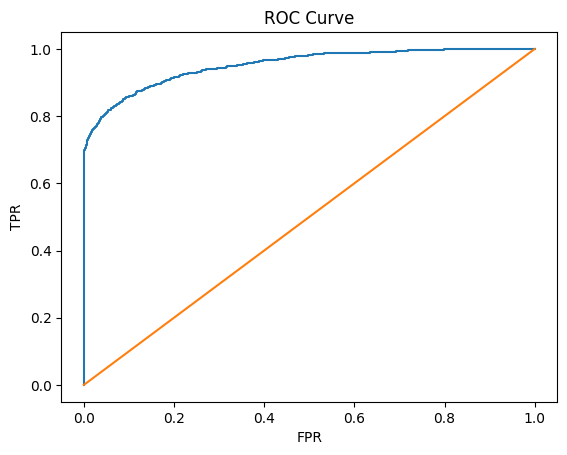

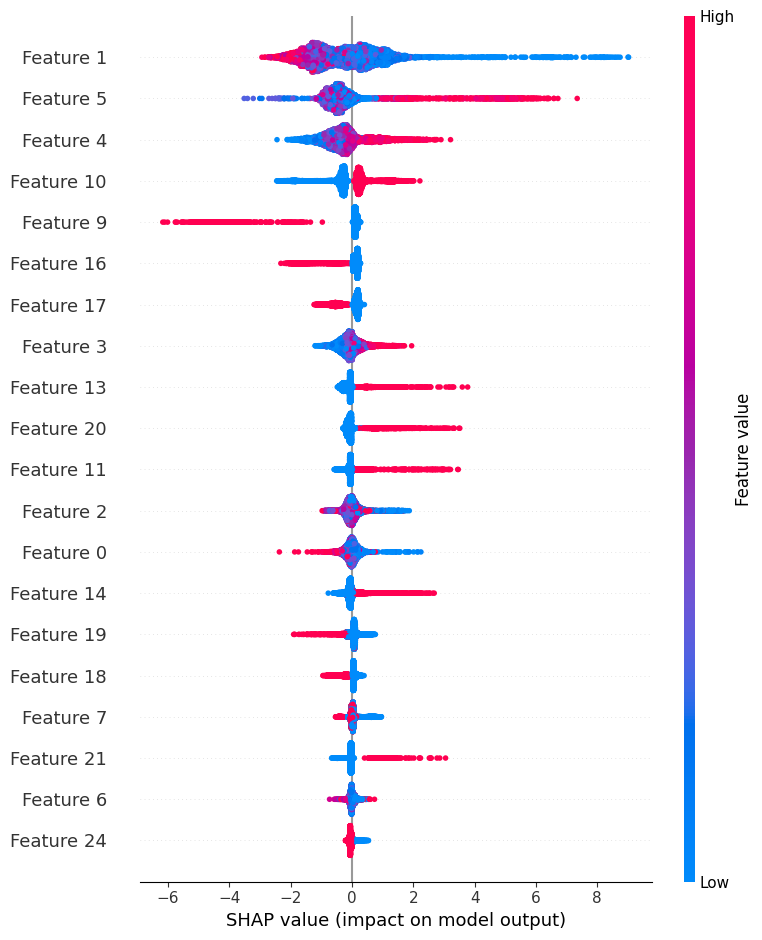

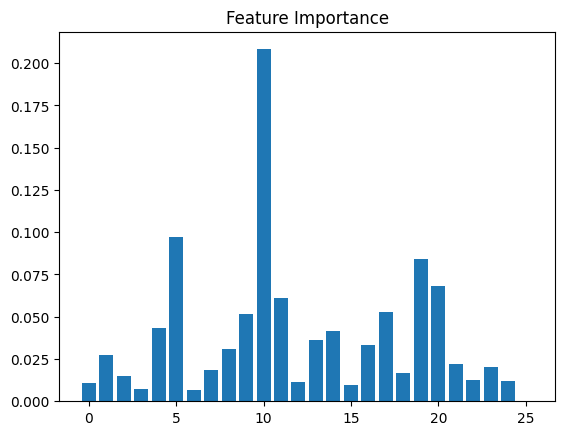

In [2]:
# =============================
# CREDIT RISK SCORING SYSTEM
# =============================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import roc_auc_score, classification_report, roc_curve

import shap
import joblib
import gradio as gr

# =============================
# 2. LOAD DATA
# =============================
df = pd.read_csv("credit_risk_dataset.csv")
print(df.head())

# Assume target column name is 'loan_status' (1 = default, 0 = non-default)
target = 'loan_status'

X = df.drop(columns=[target])
y = df[target]

# =============================
# 3. PREPROCESSING
# =============================

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# =============================
# 4. SPLIT DATA
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =============================
# 5. MODELS
# =============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}
pipelines = {}

# =============================
# 6. TRAIN & EVALUATE
# =============================
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, y_prob)

    print(f"\n{name}")
    print("ROC-AUC:", roc)
    print(classification_report(y_test, y_pred))

    results[name] = roc
    pipelines[name] = pipe

# =============================
# 7. SELECT BEST MODEL
# =============================
best_model_name = max(results, key=results.get)
best_model = pipelines[best_model_name]

print("\nBest Model:", best_model_name)

# =============================
# 8. ROC CURVE
# =============================
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

# =============================
# 9. SHAP INTERPRETATION
# =============================

# Transform data
X_transformed = best_model.named_steps['preprocessor'].transform(X_test)

explainer = shap.Explainer(best_model.named_steps['model'])
shap_values = explainer(X_transformed)

shap.summary_plot(shap_values, X_transformed)

# =============================
# 10. FEATURE IMPORTANCE
# =============================
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    plt.figure()
    plt.bar(range(len(importances)), importances)
    plt.title("Feature Importance")
    plt.show()

# =============================
# 11. SAVE MODEL
# =============================
joblib.dump(best_model, "credit_risk_model.pkl")

# =============================
# 12. GRADIO APP
# =============================

def predict_risk(*inputs):
    input_df = pd.DataFrame([inputs], columns=X.columns)
    prob = best_model.predict_proba(input_df)[0][1]
    return prob

interface = gr.Interface(
    fn=predict_risk,
    inputs=[gr.Textbox(label=col) for col in X.columns],
    outputs=gr.Number(label="Default Risk Probability")
)

# =============================
# CREDIT RISK SCORING SYSTEM
# =============================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import roc_auc_score, classification_report, roc_curve

import shap
import joblib
import gradio as gr

# =============================
# 2. LOAD DATA
# =============================
df = pd.read_csv("credit_risk_dataset.csv")
print(df.head())

# Assume target column name is 'loan_status' (1 = default, 0 = non-default)
target = 'loan_status'

X = df.drop(columns=[target])
y = df[target]

# =============================
# 3. PREPROCESSING
# =============================

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# =============================
# 4. SPLIT DATA
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =============================
# 5. MODELS
# =============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}
pipelines = {}

# =============================
# 6. TRAIN & EVALUATE
# =============================
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, y_prob)

    print(f"\n{name}")
    print("ROC-AUC:", roc)
    print(classification_report(y_test, y_pred))

    results[name] = roc
    pipelines[name] = pipe

# =============================
# 7. SELECT BEST MODEL
# =============================
best_model_name = max(results, key=results.get)
best_model = pipelines[best_model_name]

print("\nBest Model:", best_model_name)

# =============================
# 8. ROC CURVE
# =============================
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

# =============================
# 9. SHAP INTERPRETATION
# =============================

# Transform data
X_transformed = best_model.named_steps['preprocessor'].transform(X_test)

explainer = shap.Explainer(best_model.named_steps['model'])
shap_values = explainer(X_transformed)

shap.summary_plot(shap_values, X_transformed)

# =============================
# 10. FEATURE IMPORTANCE
# =============================
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    plt.figure()
    plt.bar(range(len(importances)), importances)
    plt.title("Feature Importance")
    plt.show()

# =============================
# 11. SAVE MODEL
# =============================
joblib.dump(best_model, "credit_risk_model.pkl")

# =============================
# 12. GRADIO APP
# =============================

def predict_risk(*inputs):
    input_df = pd.DataFrame([inputs], columns=X.columns)
    prob = best_model.predict_proba(input_df)[0][1]
    return prob

interface = gr.Interface(
    fn=predict_risk,
    inputs=[gr.Textbox(label=col) for col in X.columns],
    outputs=gr.Number(label="Default Risk Probability")
)

# To launch UI
# interface.launch()



In [3]:
 interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://56e95c4f32b7d20d6c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
